In [2]:
import numpy as np
import stim
import torch
import pymatching
from collections import OrderedDict
from sklearn.model_selection import train_test_split
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, Subset

print(stim.__version__)

1.15.0


In [81]:
#Surface code stabilizer circuit

circuit = stim.Circuit.generated(
    "surface_code:rotated_memory_z", # Protect a qubit stored in the z basis to detect a bit flip (logical x error)
    rounds=9,
    distance=5,
    after_clifford_depolarization=0.005, # Circuit-level (FT) noise
    after_reset_flip_probability=0.005, # Circuit-level (FT) noise
    before_measure_flip_probability=0.005, # Circuit-level (FT) noise
    before_round_data_depolarization=0.005
)

sampler = circuit.compile_detector_sampler(seed=42) #Set a seed so that things are predictable



In [82]:
# Measuring the stabilizers x- and z-ancillas. 
# Generating the samples to train the MLP decoder

n_shots = 10_000_000
syndromes, obs = sampler.sample(shots=n_shots, separate_observables=True)

# Converting to numerical numbers for computations 
labels = obs.astype(np.float32)
features = syndromes.astype(np.float32)
print(obs.shape)
print(len(features))
# From numpy to torch
labels = torch.from_numpy(labels)
features = torch.from_numpy(features)


(10000000, 1)
10000000


In [83]:
# Baseline MWPM decoder (pymatching)
# Our decoder will be compared to this later on

dem = circuit.detector_error_model(decompose_errors=True)
matcher = pymatching.Matching.from_detector_error_model(dem)

preds = matcher.decode_batch(syndromes)

print(preds[90])
# Count the mistakes.
num_errors = 0
for shot in range(n_shots):
    actual_for_shot = obs[shot]
    predicted_for_shot = preds[shot]
    if not np.array_equal(actual_for_shot, predicted_for_shot):
        num_errors += 1
print(num_errors)
print(f'LER = {num_errors/n_shots:.2%}')

[0]
262165
LER = 2.62%


In [84]:
# Dataset from syndromes measurement and logical observables

class quantum_dataset(Dataset):
    def __init__(self):
        self.features = features
        self.labels = labels
    def __len__(self):
        return len(self.features)
    def __getitem__(self, id):
        return self.features[id], self.labels[id]

dataset = quantum_dataset()

BATCH_SIZE = 128
indices = np.arange(len(dataset))
train_indices, test_indices = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=dataset.labels.numpy()
)

train_dataset = Subset(dataset, train_indices)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)
test_dataset = Subset(dataset, test_indices)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [85]:
# Neural Network Model
input_size = 216 # N_rounds = 9, N_ancillas = 8 (for distance=3)
output_size = 1
hidden_sizes = (256, 128, 64)
dropout_p = .1
model = nn.Sequential(OrderedDict([
                      ('fc1', nn.Linear(input_size, hidden_sizes[0])),
                      ('relu1', nn.ReLU()),
                      ('drp1', nn.Dropout(dropout_p)),
                      ('fc2', nn.Linear(hidden_sizes[0], hidden_sizes[1])),
                      ('relu2', nn.ReLU()),
                      #('drp2', nn.Dropout(dropout_p)),
                      ('fc3', nn.Linear(hidden_sizes[1], hidden_sizes[2])),
                      ('relu3', nn.ReLU()),
                      #('drp3', nn.Dropout(dropout_p)),
                      ('fc4', nn.Linear(hidden_sizes[2], output_size)),
                      ])
                    )

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.003) #It was 0.01

In [87]:
synds, obs = next(iter(train_loader))
ind = 32
model.eval()
o = model(synds[ind])
print(o.item(), torch.sigmoid(o).item())
print(obs.shape)
print(synds.size(0))
model.train()

0.05612325668334961 0.5140271186828613
torch.Size([128, 1])
128


Sequential(
  (fc1): Linear(in_features=216, out_features=256, bias=True)
  (relu1): ReLU()
  (drp1): Dropout(p=0.1, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (relu3): ReLU()
  (fc4): Linear(in_features=64, out_features=1, bias=True)
)

In [ ]:
# Training our MLP decoder

epochs = 50

test_losses = []
train_losses = []
acc = 0.0
saved_epoch = 1
for e in range(epochs):
    train_l = 0
    for features, labels in train_loader:
        labels = labels.view(-1, 1).float()

        optimizer.zero_grad()
        loss = criterion(model(features), labels)
        loss.backward()

        optimizer.step()

        train_l += loss.item()
    else:

        with torch.no_grad():
            model.eval()
            test_l = 0
            total_s = 0
            correct = 0

            for features, labels in test_loader:
                labels = labels.view(-1, 1).float()
                
                logits = model(features)
                loss = criterion(logits, labels)

                # Binary prediction: logit > 0 corresponds to sigmoid(logit) > 0.5
                preds = (logits > 0.0).float()
                correct += (preds == labels).sum().item()
  
                total_s += features.size(0)
                test_l += loss.item()

            model.train()

    train_losses.append(train_l/len(train_loader))
    test_losses.append(test_l/len(test_loader))
    t_acc = correct/total_s

    if t_acc > acc:
        acc = t_acc
        saved_epoch = e + 1
        torch.save(model.state_dict(), 'ch_point.pth')
    print(f"Epoch {e+1}/{epochs}: -*-*-*-*-*-")
    print(f"Training Loss = {train_l/len(train_loader)}")
    print(f"Validation Loss = {test_l/len(test_loader)}")
    print(f"Accuracy = {correct/total_s}")

print(f"Highest accuracy: {acc:3f}")


Epoch 1/50: -*-*-*-*-*-
Training Loss = 0.2957638924708366
Validation Loss = 0.23396191842603684
Accuracy = 0.8934815
Epoch 2/50: -*-*-*-*-*-
Training Loss = 0.23790637784314156
Validation Loss = 0.21443826281499861
Accuracy = 0.903555
Epoch 3/50: -*-*-*-*-*-
Training Loss = 0.22489965606749057
Validation Loss = 0.2078495658249855
Accuracy = 0.906649
Epoch 4/50: -*-*-*-*-*-
Training Loss = 0.217910612062335
Validation Loss = 0.20394704309940337
Accuracy = 0.9090915
Epoch 5/50: -*-*-*-*-*-
Training Loss = 0.21303635341084004
Validation Loss = 0.19817093995141982
Accuracy = 0.911328
Epoch 6/50: -*-*-*-*-*-
Training Loss = 0.2092471857470274
Validation Loss = 0.19428844675207138
Accuracy = 0.9134395
Epoch 7/50: -*-*-*-*-*-
Training Loss = 0.20635049324321747
Validation Loss = 0.19714000202703477
Accuracy = 0.9131315
Epoch 8/50: -*-*-*-*-*-
Training Loss = 0.2035990273629427
Validation Loss = 0.18883557283544541
Accuracy = 0.9167985
Epoch 9/50: -*-*-*-*-*-
Training Loss = 0.201504658818483

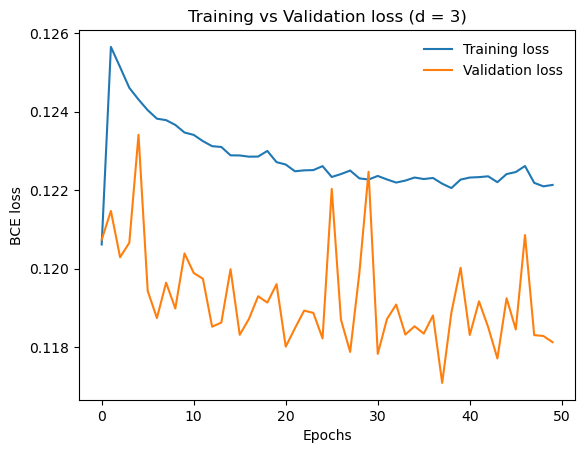

In [73]:
# Trained for 651min ~ 10hr51min. This was 50 epochs
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Training loss')
plt.plot(test_losses, label='Validation loss')
plt.title('Training vs Validation loss (d = 3)')
plt.xlabel('Epochs')
plt.ylabel('BCE loss')
plt.legend(frameon=False)

In [74]:
state_dict = torch.load('ch_point.pth')
model.load_state_dict(state_dict)

C:\Users\Cesaire\AppData\Local\Temp\ipykernel_12720\1287654157.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('ch_point.pth')


<All keys matched successfully>

In [79]:
f, l = next(iter(test_loader))
model.eval()
print(f[0].shape)
with torch.no_grad():
    o = model(f)
print(o[61], l[61])
print(criterion(o[61], l[61]))
v = torch.tensor([1 if e > 0.0 else 0 for e in o])
v = v.view(l.shape)
print(v.shape)
print(sum (l == v))

torch.Size([72])
tensor([-9.7702]) tensor([0.])
tensor(5.7220e-05)
torch.Size([128, 1])
tensor([124])


In [80]:
print(f"Highest accuracy: {acc:.4f}")
print(f"Saved epoch: {saved_epoch}")

Highest accuracy: 0.9574
Saved epoch: 49


In [21]:
def extract_error_instructions_from_dem(dem):
    """
    Extract error instructions from dem. 

    The detector error model (dem) is a list of all the independent error mechanisms in a circuit
    as well as their symptoms (which detectors the fire/set off).

    A detector is a comparison between 2 ancillas measurment.

    Parameters
        ----------
        dem              : the detector error model
    
        Returns
        -------
        e_instructions : error instructions list
    """
    e_instructions = []

    for instr in dem.flattened(): #Flattened because we need to extract error from within the circuit rounds
        if instr.type == "error":
             e_instructions.append(instr)

    return e_instructions

In [22]:
error_instrs = extract_error_instructions_from_dem(dem)
L = len(error_instrs)

In [ ]:
def E_to_synds_and_label(dem, E):
    """
    Given a binary error pattern E over DEM error mechanisms,
    compute the resulting syndrome and logical observable by XOR-ing
    the effects of all active error mechanisms.

    Parameters
        ----------
        dem              : the detector error model
        E                : binary vector, shape (L,), one entry per DEM error mechanism

        Returns
        -------
        syndrome : binary array, shape (num_detectors,)
        label    : int in {0, 1}  — 1 if logical X error occurred
    """
    num_detectors = dem.num_detectors # N_ancillas X N_rounds
    num_observables = dem.num_observables # 1

    synds = np.zeros(num_detectors, dtype=np.int8)
    logical = np.zeros(num_observables, dtype=np.int8)

    e_instructions = extract_error_instructions_from_dem(dem)

    for i, e_instr in enumerate(e_instructions):
        if E[i] == 1:
            # XOR the detectors this error flips. A target is a detector
            for target in e_instr.targets_copy():
                if target.is_relative_detector_id(): 
                    synds[target.val] ^= 1
                elif target.is_logical_observable_id():
                    print(f'Detector that triggers the logical observables: {target.val}')
                    logical[target.val] ^= 1

    label = float(logical[0])  # 1 = logical X error occurred
    return synds.astype(np.float32), label

In [ ]:
def simulated_annealing_attack(
    model,
    dem: stim.DetectorErrorModel,
    L: int,                    # total number of error locations (len of E which is the len of dem error instructions )
    W: int,                    # error budget. Hamming weight of E, fixed
    T0: float     = 2.0,       # initial annealing temperature
    T_min: float  = 0.1,       # stopping temperature
    cooling: float = 0.995,    # geometric cooling rate gamma
    steps_per_T: int = 20,     # Metropolis steps per temperature level
    n_restarts: int  = 5,      # independent SA chains
    seed: int        = 0,
):
    """
    Finds the error pattern E* in A_W = {E : |E| = W} that maximises
    the Binary Cross Entropy (BCE) loss of the decoder, i.e. the most adversarial X-error pattern
    within the given budget.

    Move set: swap (remove one active fault, add one inactive fault)
    → preserves |E| = W exactly throughout.

    Returns
    -------
    best_E      : binary array, shape (L,)  — worst-case error pattern
    best_loss   : float                     — BCE loss at best_E
    best_S      : float32 array             — syndrome produced by best_E
    best_label  : int                       — ground-truth label at best_E
    """
    rng = np.random.default_rng(seed)

    best_E     = None
    best_loss  = -np.inf
    best_S     = None
    best_label = None
    n_detectors = dem.num_detectors # N_ancillas X N_rounds

    for restart in range(n_restarts):

        # ── initialise: random pattern of exact weight W ──────────────────
        E = np.zeros(L, dtype=np.int8)
        init_idx = rng.choice(L, size=W, replace=False)
        E[init_idx] = 1

        S, label   = E_to_synds_and_label(dem, E)

        #Transform the syndrome vector S and the ground truth label to fit in the model
        label = torch.tensor([label])
        S = torch.from_numpy(S)
        S = S.view(n_detectors)
        label = label.view(1)

        #Compute the BCE loss
        curr_loss  = criterion(model(S), label)

        local_best_E    = E.copy()
        local_best_loss = curr_loss
        local_best_S    = S.clone()
        local_best_label = label

        T = T0

         # ── annealing loop ────────────────────────────────────────────────
        while T > T_min:
            for _ in range(steps_per_T):

                # swap move: keeps |E| = W
                on_idx  = np.flatnonzero(E == 1)
                off_idx = np.flatnonzero(E == 0)
                i_remove = rng.choice(on_idx)
                i_add    = rng.choice(off_idx)

                E_new = E.copy()
                E_new[i_remove] = 0
                E_new[i_add]    = 1

                S_new, label_new = E_to_synds_and_label(
                    dem, E_new)

                #Transform the syndrome vector S and the ground truth label to fit in the model
                label_new = torch.tensor([label_new])
                S_new = torch.from_numpy(S_new)
                S_new = S_new.view(n_detectors)
                label_new = label_new.view(1)

                new_loss = criterion(model(S_new), label_new)

                # Metropolis–Hastings acceptance
                delta = new_loss - curr_loss
                delta = delta.item()
                if delta > 0 or rng.random() < np.exp(delta / T):
                    E, curr_loss = E_new, new_loss
                    S, label     = S_new, label_new

                    if curr_loss > local_best_loss:
                        local_best_E     = E.copy()
                        local_best_loss  = curr_loss
                        local_best_S     = S.clone()
                        local_best_label = label

            T *= cooling   # geometric cooling
            #print(local_best_loss.item(), '\n', local_best_S, '\n', local_best_label)

             # update global best across restarts
        if local_best_loss > best_loss:
            best_loss  = local_best_loss
            best_E     = local_best_E.copy()
            best_S     = local_best_S.clone()
            best_label = local_best_label

        if (restart + 1) % 1 == 0:
            print(f"  restart {restart+1}/{n_restarts} | "
                  f"best BCE loss so far: {best_loss:.4f}")

    return best_E, best_loss, best_S, best_label

In [51]:

best_E, best_loss, best_S, best_label = simulated_annealing_attack(model, dem, L, 2, n_restarts=50)

  restart 1/50 | best BCE loss so far: 7.3606
  restart 2/50 | best BCE loss so far: 7.3606
  restart 3/50 | best BCE loss so far: 7.3606
  restart 4/50 | best BCE loss so far: 7.3606
  restart 5/50 | best BCE loss so far: 7.4200
  restart 6/50 | best BCE loss so far: 7.4200
  restart 7/50 | best BCE loss so far: 7.4200
  restart 8/50 | best BCE loss so far: 7.4200
  restart 9/50 | best BCE loss so far: 7.4200
  restart 10/50 | best BCE loss so far: 7.4200
  restart 11/50 | best BCE loss so far: 7.4200
  restart 12/50 | best BCE loss so far: 7.4200
  restart 13/50 | best BCE loss so far: 7.4200
  restart 14/50 | best BCE loss so far: 7.4200
  restart 15/50 | best BCE loss so far: 7.4200
  restart 16/50 | best BCE loss so far: 7.4200
  restart 17/50 | best BCE loss so far: 7.4200
  restart 18/50 | best BCE loss so far: 7.4200
  restart 19/50 | best BCE loss so far: 7.4200
  restart 20/50 | best BCE loss so far: 7.4200
  restart 21/50 | best BCE loss so far: 7.4200
  restart 22/50 | best

In [55]:
print(best_label)
model(best_S)

tensor([0.])


tensor([7.4573], grad_fn=<ViewBackward0>)

In [26]:
L = len(dem.flattened())
print(dem.num_errors, L)
instructions = []
for instr in dem.flattened():
    
    if instr.type == "error":
        #print(instr)
        instructions.append(instr)

E = np.zeros(L, dtype=np.int8)
S, obs = E_to_synds_and_label(dem, E)

obs = torch.tensor([obs])
S = torch.from_numpy(S)
S= S.view(dem.num_detectors)
obs = obs.view(1)
print(S.shape)
#S.reshape(1, dem.num_detectors)
print(obs.shape)

1256 1328
torch.Size([72])
torch.Size([1])
